In [1]:
"""
Created By    : Jared W. Marquis
Creation Date : 01 August 2022
Course        : ATSC 528 - Atmospheric Data Analysis
Assignment    : #01 - Function Fitting

Purpose:
Script to take sparse upper air observations and analyze them on a
polar stereographic map projection using function fitting.
[PUT MORE INFORMATION HERE - I.E., WHAT SPECIFIC THING IS BEING DONE]

"""
__author__    = "Jared W. Marquis"
__contact__   = "jared.marquis@und.edu"

In [5]:
### Import Required Modules (shouldn't need to change) ###
import numpy as np                 #numpy for math
import matplotlib.pyplot as plt    #matplotlib for plotting
import cartopy.crs as ccrs         #cartopy for plotting on map
import cartopy.feature as cfeature #cartopy basic shapefiles

In [6]:
### Read in observations ###
raw_obs = np.loadtxt("RAOBs_201903131200.txt", delimiter=',', dtype=str)

In [7]:
### Set up analysis map with a 21x27 rectangular grid of points ###

# params
R = 6371.0
phi_0 = np.deg2rad(60.0)
lambd_0 = np.deg2rad(-100.0)
k_0 = (1+np.sin(phi_0))/2

R_map = R * 100000 /15000000

rho = 6371000

# grid points 
nx = 21
ny = 27
dx, x_0 = 1.27, 25
dy, y_0 = 1.27, -15.5
x = x_0 + np.arange(nx) * dx
y = y_0 + np.arange(ny) * dy
x_grid, y_grid = np.meshgrid(x, y, indexing='ij')

print(f'x: {x}\ny: {y}\nR_map: {R_map}')

x: [25.   26.27 27.54 28.81 30.08 31.35 32.62 33.89 35.16 36.43 37.7  38.97
 40.24 41.51 42.78 44.05 45.32 46.59 47.86 49.13 50.4 ]
y: [-15.5  -14.23 -12.96 -11.69 -10.42  -9.15  -7.88  -6.61  -5.34  -4.07
  -2.8   -1.53  -0.26   1.01   2.28   3.55   4.82   6.09   7.36   8.63
   9.9   11.17  12.44  13.71  14.98  16.25  17.52]
R_map: 42.473333333333336


In [8]:
### convert obs lat/long to x,y (may want to plot on your analysis grid to verify)###

# open raw lat/lon
raw_lats = [float(raw_obs[i][1]) for i in range(len(raw_obs))]
raw_lons = [float(raw_obs[i][2]) for i in range(len(raw_obs))]

# convert to rad and create lambda
phi = np.deg2rad(raw_lats)
lamdb = np.deg2rad(raw_lons) - lambd_0

# eqn for r: r = rho * sigma * cos(phi).....or..... r= R*(1+sin(phi_0)/1+sin(phi))*cos(phi)
r = R * ((1 + np.sin(phi_0))/(1 + np.sin(phi))) * np.cos(phi) /150 

# convert
x_ob = r * np.cos(lamdb)
y_ob = r * np.sin(lamdb)

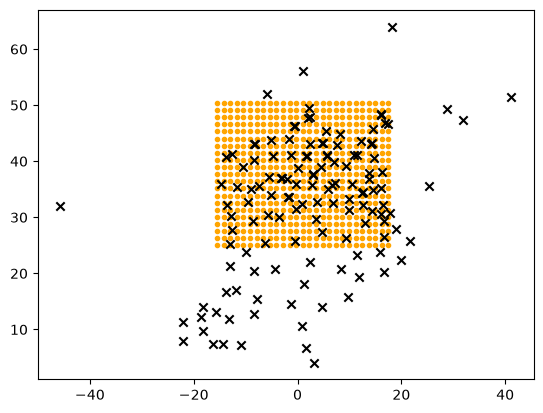

In [9]:
# simple test of grid and obs
plt.scatter(y_grid, x_grid, marker=".", color='orange')
plt.scatter(y_ob, x_ob, marker='x', color='k')

In [10]:
### Perform 500mb geopotential height analyses using a second order 2-d polynomial with two ###
### radii of influence (10cm & 20cm) ###

raw_500s = np.array([float(raw_obs[i][3]) for i in range(len(raw_obs))])

# function to run matrix for both rois
def run_matrix(raw_data, roi):

    # empty arrs for storing info
    analysis_pts = np.full(x_grid.shape, np.nan)
    number_of_obs = np.zeros(x_grid.shape)

    for x in range(x_grid.shape[0]):
        for y in range(x_grid.shape[1]):
            
            # define grid pts and rel distance between grid pt and obs
            x_grid_pt, y_grid_pt = x_grid[x, y], y_grid[x, y]
            rel_dist = np.sqrt((x_ob - x_grid_pt)**2 + (y_ob - y_grid_pt)**2)

            # save sum of true bools if rel dist is inside roi
            inside_roi_bool = rel_dist <= roi
            number_of_obs[x,y] = np.sum(inside_roi_bool) 

            if np.sum(inside_roi_bool) < 6:
                continue

            # extract rel corrdinates and ob val if inside roi
            xk, yk = x_ob[inside_roi_bool] - x_grid_pt, y_ob[inside_roi_bool] - y_grid_pt
            fk = raw_data[inside_roi_bool]

            # make matrix
            poly = [np.ones(np.sum(inside_roi_bool)), xk, yk, xk**2, yk**2, xk*yk]
            matrix_lhs = np.array([[np.sum(poly[row]*poly[col]) for col in range(len(poly))] for row in range(len(poly))])
            matrix_rhs = np.array([np.sum(poly[row]*fk) for row in range(len(poly))])

            # numpy tool to solve matrix
            coeff = np.linalg.solve(matrix_lhs, matrix_rhs)
            analysis_pts[x,y] = coeff[0]

    return analysis_pts, number_of_obs

# run matrix for boths rois
analysis_pts_10, number_of_obs_10 = run_matrix(raw_500s, 10)
analysis_pts_20, number_of_obs_20 = run_matrix(raw_500s, 20)

In [15]:
analysis_pts_10[0]

array([5556.72236017, 5505.67360381, 5466.68216192, 5429.11781791,
       5393.13185705, 5372.34713932, 5344.99284016, 5348.12290445,
       5330.69374221, 5334.48398096, 5338.34345402, 5342.47954516,
       5355.24808662, 5371.61097449, 5373.02932731, 5374.70033847,
       5369.64215153, 5365.52576996, 5368.50072449, 5377.58320139,
       5398.2725802 , 5404.67921088, 5411.20245124, 5433.65967303,
       5444.42465733, 5447.24119631, 5448.72499994])

In [8]:
# convert pts back to lat/lon for plotting
r = np.sqrt(x_grid**2 + y_grid**2)
phi = (np.pi/2 - 2*np.arctan(r/(R_map * (1 +np.sin(phi_0)))))
lambd = np.arctan2(y_grid, x_grid)
lon = np.rad2deg(lambd_0 + lambd)
lat = np.rad2deg(phi)

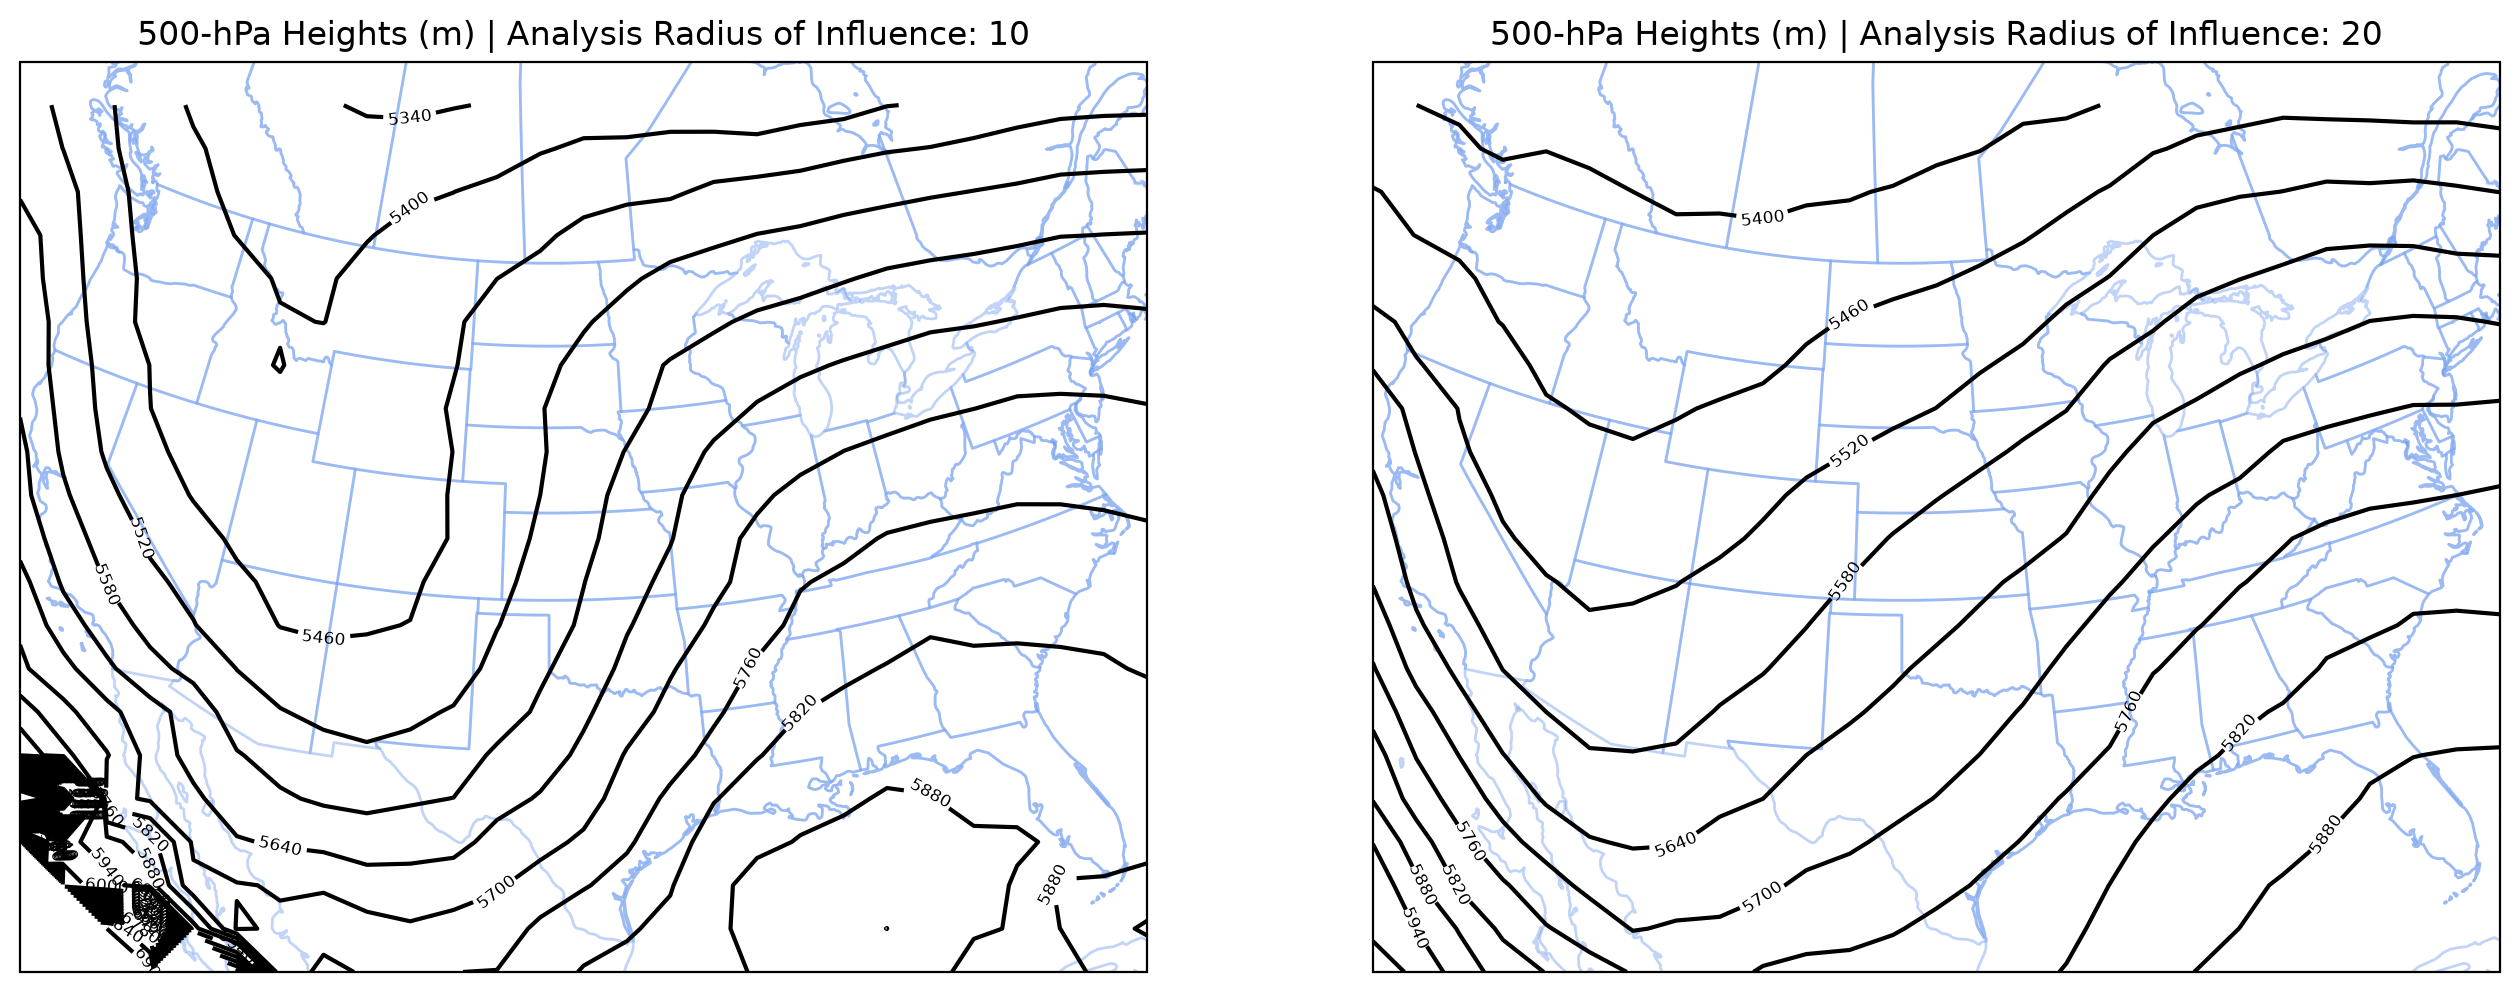

In [ ]:
### Plot 500mb analyses over a map ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=-100, central_latitude=90, true_scale_latitude=60, globe=globe)

fig, axes = plt.subplots(1,2, figsize=(16,8), dpi=200, subplot_kw={'projection':proj})

#fig = plt.figure(figsize=(8,8),dpi=200)
#ax1 = fig.add_subplot(111,projection=proj)

analysis_data = [analysis_pts_10, analysis_pts_20]
rois = ["10", "20"]

for i in range(0,2):
    axes[i].add_feature(cfeature.STATES, edgecolor='cornflowerblue', alpha=0.4)
    axes[i].add_feature(cfeature.COASTLINE, edgecolor='cornflowerblue', alpha=0.4)
    cs1 = axes[i].contour(lon,lat,analysis_data[i],colors='k', levels=np.arange(0,8000,60),transform=ccrs.PlateCarree())
    plt.clabel(cs1,levels=np.arange(0,8000,60), fontsize=6)
    axes[i].set_title(f"500-hPa Heights (m) | Analysis Radius of Influence: {rois[i]}")
    
plt.show()

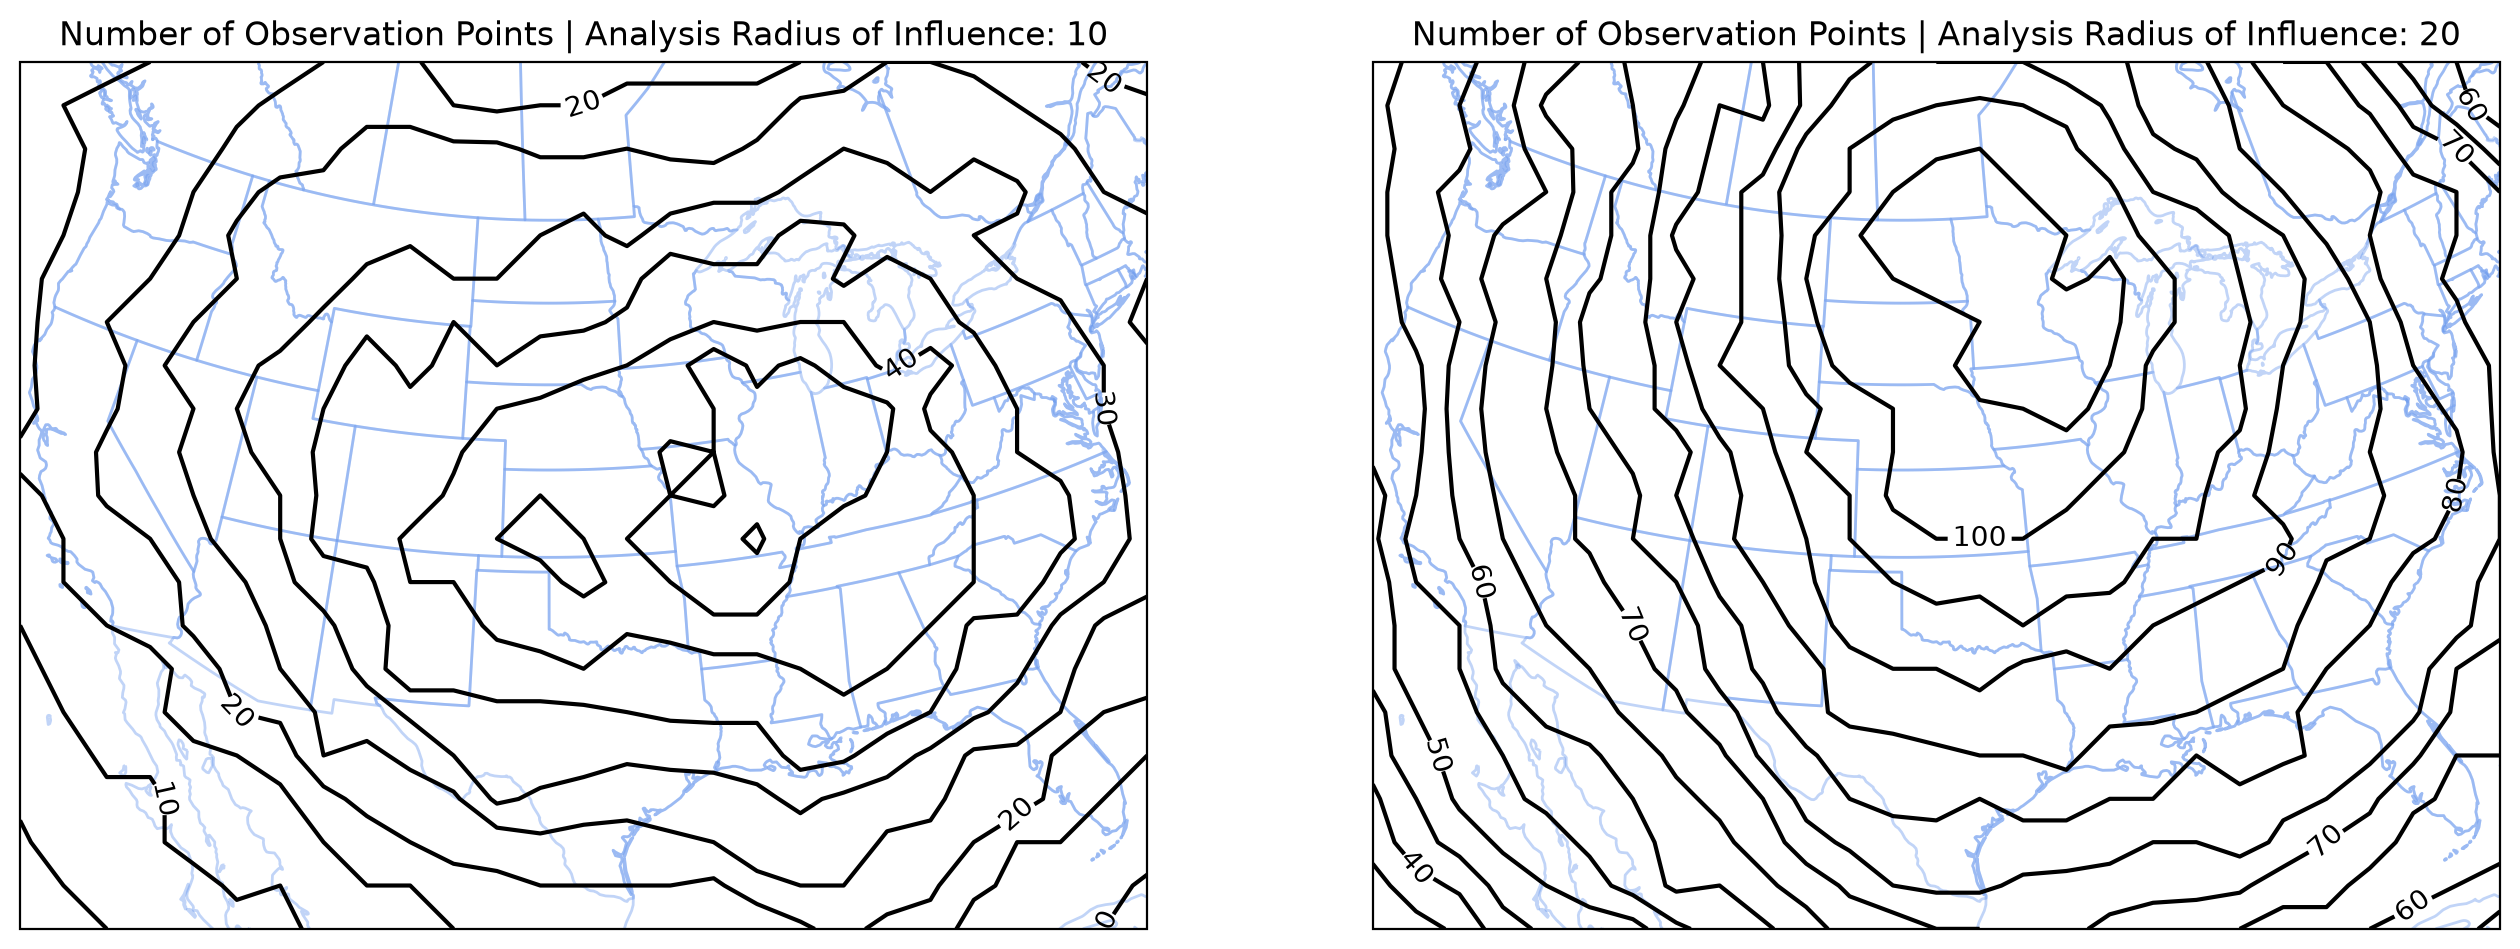

In [28]:
### Plot 500mb analyses over a map ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=-100, central_latitude=90, true_scale_latitude=60, globe=globe)

fig, axes = plt.subplots(1,2, figsize=(16,8), dpi=200, subplot_kw={'projection':proj})

#fig = plt.figure(figsize=(8,8),dpi=200)
#ax1 = fig.add_subplot(111,projection=proj)

analysis_data = [number_of_obs_10, number_of_obs_20]
rois = ["10", "20"]

for i in range(0,2):
    axes[i].add_feature(cfeature.STATES, edgecolor='cornflowerblue', alpha=0.4)
    axes[i].add_feature(cfeature.COASTLINE, edgecolor='cornflowerblue', alpha=0.4)
    cs1 = axes[i].contour(lon, lat, analysis_data[i], colors='k',
                  levels=np.arange(0,200,5),transform=ccrs.PlateCarree())
    plt.clabel(cs1,levels=np.arange(0,200,10))
    axes[i].set_title(f"Number of Observation Points | Analysis Radius of Influence: {rois[i]}")

plt.show()

In [ ]:
### Store the analyses in text files ###

# NOTE: writing obs, analysis, x/y, etc together in the same file. One file for roi=10 and one for roi=20

def write_file(fn, analysis_pts, number_of_obs):
    with open(fn, "w") as f:

        f.write("x, y, x_cm, y_cm, lat, lon, analysis, number_of_obs\n")

        for x in range(x_grid.shape[0]):
            for y in range(x_grid.shape[1]):
                f.write(f"{int(x)}, " f"{int(y)}, "
                        f"{np.round(x_grid[x,y], 4)}, " f"{np.round(y_grid[x,y], 4)}, "
                        f"{np.round(lat[x,y], 4)}, " f"{np.round(lon[x,y], 4)}, "
                        f"{np.round(analysis_pts[x,y], 6)}, " f"{int(number_of_obs[x,y])}, \n")

write_file("roi10.txt", analysis_pts_10, number_of_obs_10)
write_file("roi20.txt", analysis_pts_20, number_of_obs_20)

In [ ]:
### In a separte text file (or below), answer the following questions ###
'''
###############################################################################################################
1 - Describe the general features that you see in your contoured analyses.
    -----------------------------------------------------------------------
    The primary feature is a large scale trof extending from the southern Canadian Rockies 
    southward into far northern Mexico. Depending on the ROI, the trof appears to exhibit a weak negative tilt.
    Elsewhere, a ridge is located over the Gulf of Mexico. 


###############################################################################################################    
2 - Describe the differences that you see in your contoured analyses.  
    Does one analysis seem to be smoother than the other?  If so, what would cause this?
    -------------------------------------------------------------------------------------
    The foremost difference is the appearance of the features. A larger ROI analysis happens to smooth out
    smaller features, giving the trof more of a neutral tilt. Including the influence of observations further
    away from a given point dampens local gradients and extremes, smoothing the field. A smaller ROI, however,
    does introduce a bit of noisy contour behavior around the analysis domain edges where available data is sparse. 
    This is a result of insufficient data on all side of the point, making the function fitting less accurate.
    

###############################################################################################################
3 - Run your program using a radius of influence of 6 cm (do not need to show).  
    Describe the results - do they look realistic?  If there are problems, what
    do you think might be causing them?
    ----------------------------------------------------------------------------
    Using ROI=6 greatly reduces the number of contours because not enough observations are available to run
    the matrix. Many contours are missing, broken, or feature far more unrealistic behavior along the domain 
    boundaries. The matrix becomes unsolvable in many locations due to insufficient observations, resulting in
    broken contours. 


###############################################################################################################
4 - Suppose you ran this program with a small enough radius of influence that only one
    observation was available for determining a polynomial fit at a grid point.  Should
    you be able to perform the matrix inversion?  Why or why not?
    -----------------------------------------------------------------------------
    No, the matrix would be severely underdetermined and the matrix shouldn't be invertable, thus unsolvable. 

'''

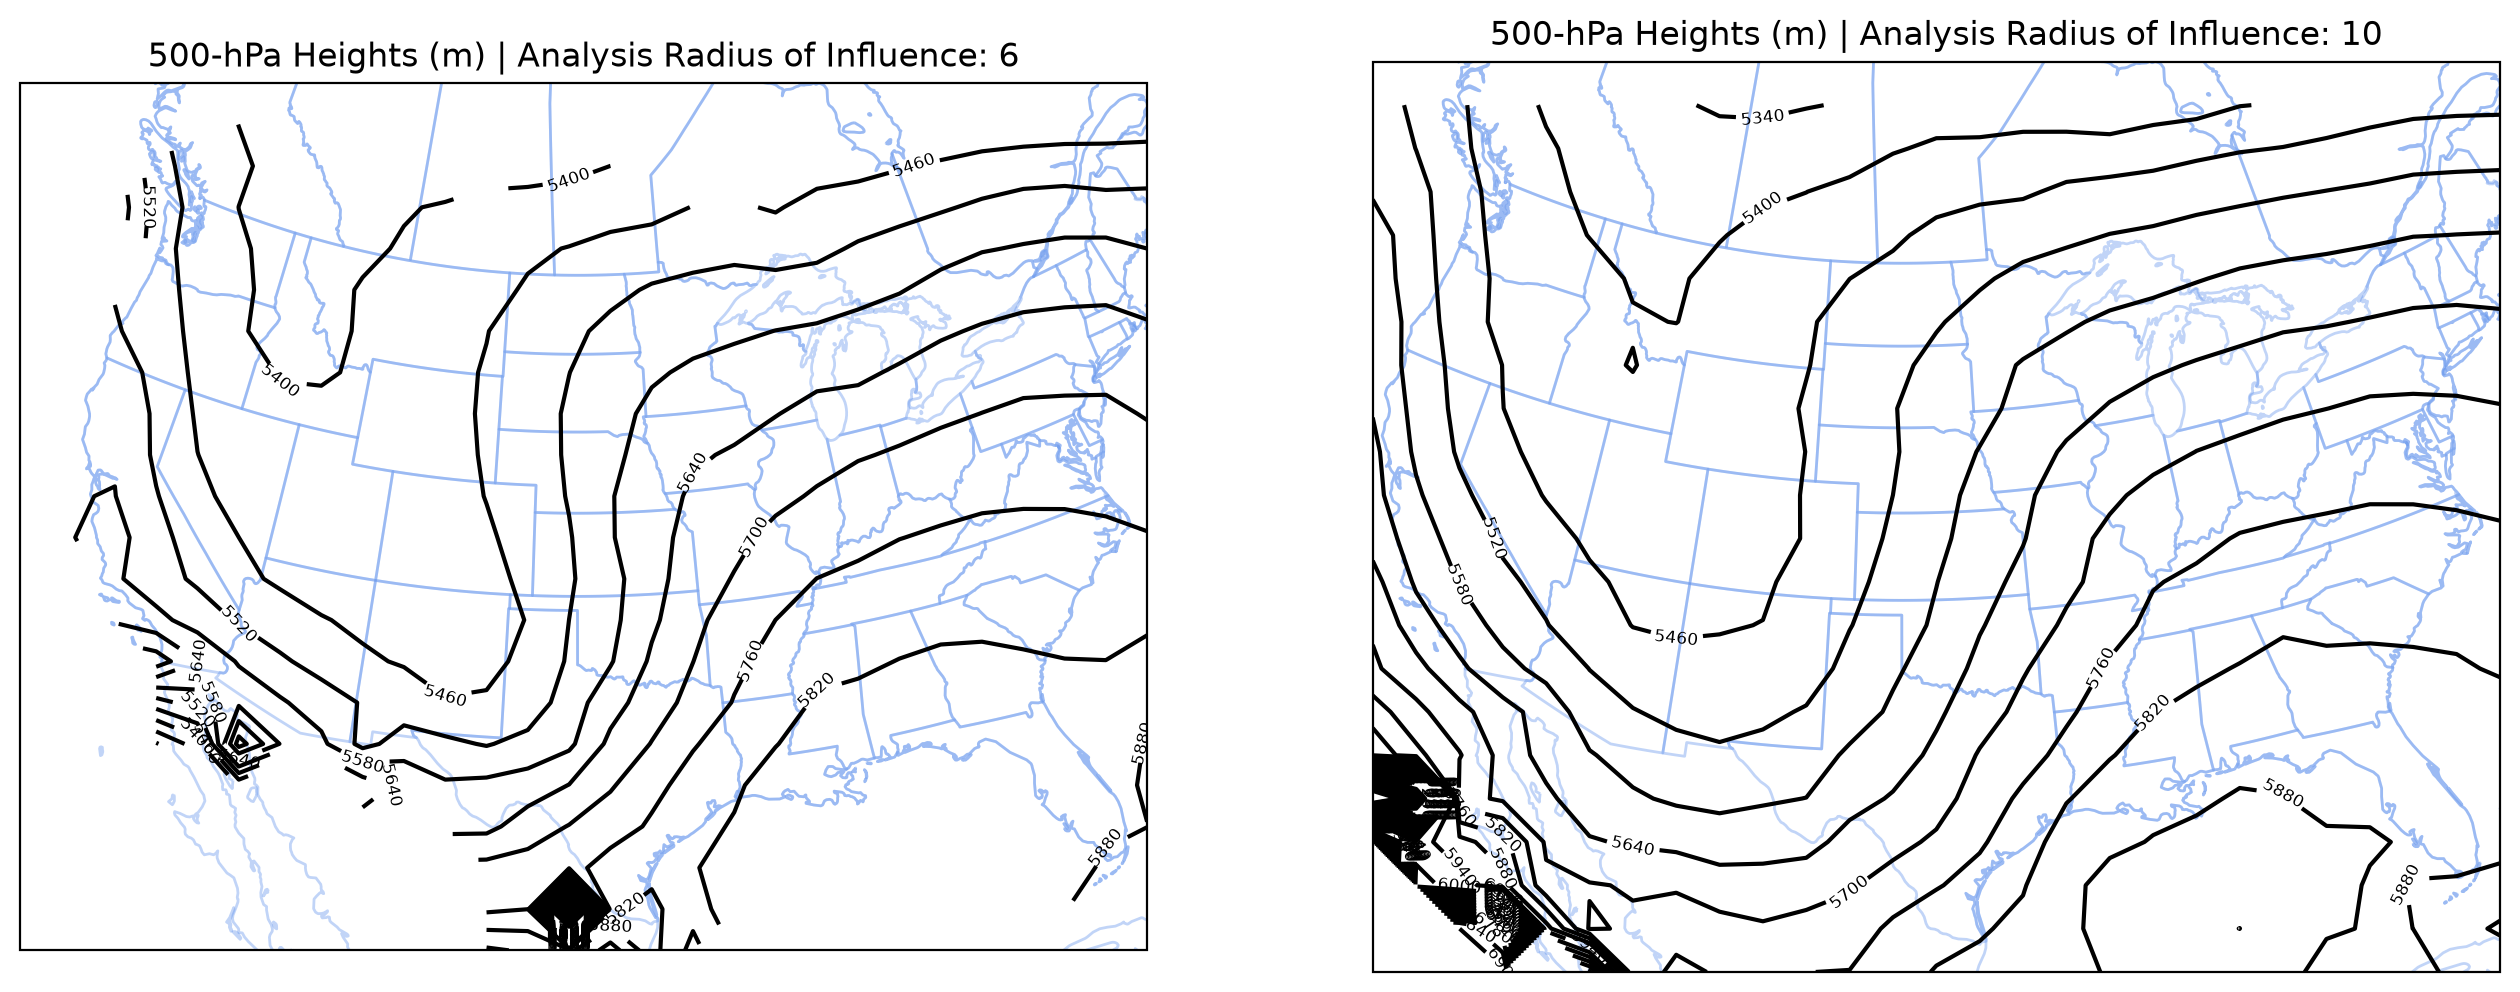

In [36]:
analysis_pts_6, number_of_obs_6 = run_matrix(raw_500s, 6)

### Plot 500mb analyses over a map ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=-100, central_latitude=90, true_scale_latitude=60, globe=globe)

fig, axes = plt.subplots(1,2, figsize=(16,8), dpi=200, subplot_kw={'projection':proj})

#fig = plt.figure(figsize=(8,8),dpi=200)
#ax1 = fig.add_subplot(111,projection=proj)

analysis_data = [analysis_pts_6, analysis_pts_10]
rois = ["6", "10"]

for i in range(0,2):
    axes[i].add_feature(cfeature.STATES, edgecolor='cornflowerblue', alpha=0.4)
    axes[i].add_feature(cfeature.COASTLINE, edgecolor='cornflowerblue', alpha=0.4)
    cs1 = axes[i].contour(lon,lat,analysis_data[i],colors='k', levels=np.arange(0,8000,60),transform=ccrs.PlateCarree())
    plt.clabel(cs1,levels=np.arange(0,8000,60), fontsize=6)
    axes[i].set_title(f"500-hPa Heights (m) | Analysis Radius of Influence: {rois[i]}")
    
plt.show()